In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import saspy

# Theory note: see proc_output_universal_pattern.md in this folder.
sas = saspy.SASsession()
sas

Using SAS Config named: oda_euw1
SAS Connection established. Subprocess id is 6796



Access Method         = IOM
SAS Config name       = oda_euw1
SAS Config file       = C:\Users\yzdom/.config/saspy\sascfg_personal.py
WORK Path             = /saswork/SAS_workC03E00015022_odaws02-euw1.oda.sas.com/SAS_work7C9900015022_odaws02-euw1.oda.sas.com/
SAS Version           = 9.04.01M8P02222023
SASPy Version         = 5.103.0
Teach me SAS          = False
Batch                 = False
Results               = Pandas
SAS Session Encoding  = utf-8
Python Encoding value = utf-8
SAS process Pid value = 86050
SASsession started    = Tue May  5 23:52:50 2026


In [ ]:
# Build a clean analysis table from sashelp.heart
sas.submitLST(
    """
data work.heart2;
    set sashelp.heart(keep=weight_status smoking_status);
    where not missing(weight_status) and not missing(smoking_status);
run;
""",
    method="listonly",
)

_lib, _tbl = "work.heart2".split(".")
df_h = sas.sasdata(_tbl, _lib).head()
df_h

,Weight_Status,Smoking_Status
0,Overweight,Non-smoker
1,Overweight,Non-smoker
2,Overweight,Moderate (6-15)
3,Overweight,Non-smoker
4,Overweight,Heavy (16-25)


 ## Interactive cell 1: output shown in results only (no output datasets requested)
 ####################################################################################################

In [ ]:
sas.submitLST(
    """
title "PROC FREQ with Somers' D (display only)";
proc freq data=work.heart2;
    tables weight_status*smoking_status / all;
run;
title;
""",
    method="listonly",
)

 ## Interactive cell 2: same analysis, now also capture ODS tables as datasets (<=20 SAS lines)
 ####################################################################################################

In [ ]:
# ods trace
sas.submitLST(
    """
ods trace on;
proc freq data=work.heart2;
    tables weight_status*smoking_status / measures;
run;
ods trace off;
""",
    method="listandlog",
)

26                                                         The SAS System                          Tuesday, May  5, 2026 10:52:00 PM

152        ods listing close;ods html5 (id=saspy_internal) file=_tomods1 options(bitmap_mode='inline') device=svg style=Raven; ods
152      ! graphics on / outputfmt=png;
153        
154        
155        ods trace on;
156        proc freq data=work.heart2;
157            tables weight_status*smoking_status / measures;
158        run;

Output Added:
-------------
Name:       CrossTabFreqs
Label:      Cross-Tabular Freq Table
Template:   Base.Freq.CrossTabFreqs
Path:       Freq.Table1.CrossTabFreqs
-------------

Output Added:
-------------
Name:       Measures
Label:      Measures of Association
Template:   Base.Freq.Measures
Path:       Freq.Table1.Measures
-------------
159        ods trace off;
160        
161        
162        
163        ods html5 (id=saspy_internal) close;ods listing;
164        
27                                              

In [ ]:
sas.submitLST(
    """
title "PROC FREQ with Somers' D (capture ODS tables)";
ods output Measures=work.freq_measures CrosstabFreqs=work.freq_cells;
proc freq data=work.heart2;
    tables weight_status*smoking_status / measures;
run;
ods output close;
title;
""",
    method="listonly",
)

In [ ]:
# Simple inspect cell (5 SAS lines)
sas.submitLST(
    """
proc contents data=work.freq_measures; run;
proc print data=work.freq_measures(obs=10); run;
""",
    method="listonly",
)

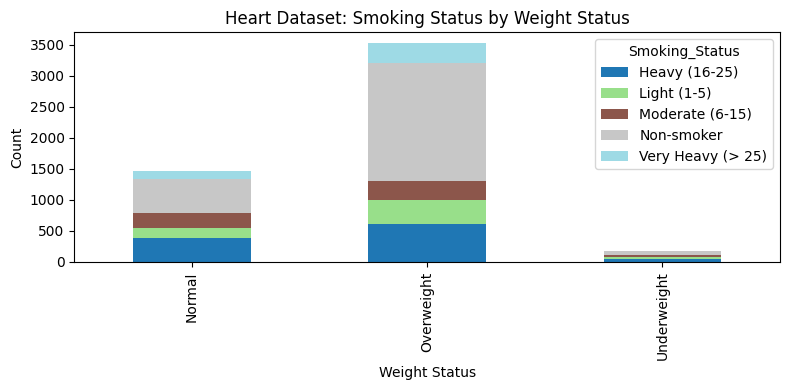

In [ ]:
# Simple Python plot (~10 lines): stacked counts by weight_status and smoking_status
cells = sas.sasdata2dataframe(table="freq_cells", libref="work")
plot_df = (
    cells.loc[
        cells["_TYPE_"].eq("11"), ["Weight_Status", "Smoking_Status", "Frequency"]
    ]
    .pivot_table(
        index="Weight_Status",
        columns="Smoking_Status",
        values="Frequency",
        aggfunc="sum",
    )
    .fillna(0)
)
ax = plot_df.plot(kind="bar", stacked=True, figsize=(8, 4), colormap="tab20")
ax.set_title("Heart Dataset: Smoking Status by Weight Status")
ax.set_xlabel("Weight Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

 ## Interactive cell 3: Explicit `OUTPUT` statements (common in modeling procedures).
 ####################################################################################################

In [ ]:
# Run PROC LOGISTIC on sashelp.heart; OUTPUT OUT= writes predicted probs row-by-row.
sas.submitLST(
    """
proc logistic data=sashelp.heart;
    where status in ('Alive', 'Dead');
    model status(event='Dead') = weight smoking;
    output out=work.heart_pred p=p_dead;
run;
""",
    method="listonly",
)

In [ ]:
# Inspect the output dataset schema and first rows
sas.submitLST(
    """
proc contents data=work.heart_pred; run;
proc print data=work.heart_pred(obs=10); var status weight smoking p_dead; run;
""",
    method="listonly",
)

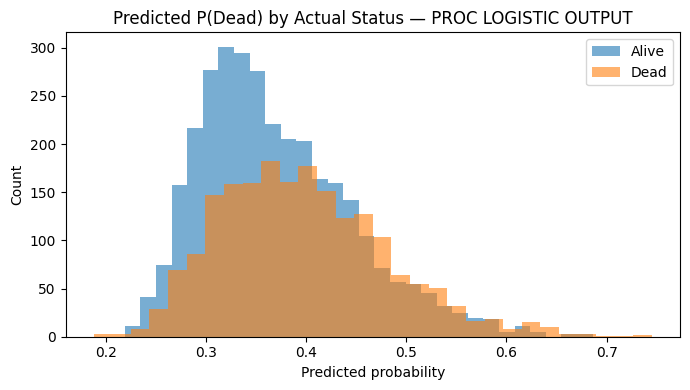

In [ ]:
# Python plot: distribution of predicted probability of death by actual status
df_pred = sas.sasdata2dataframe(table="heart_pred", libref="work")
fig, ax = plt.subplots(figsize=(7, 4))
for label, grp in df_pred.groupby("Status"):
    ax.hist(grp["p_dead"], bins=30, alpha=0.6, label=label)
ax.set_title("Predicted P(Dead) by Actual Status — PROC LOGISTIC OUTPUT")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
sas.submitLST(
    f"""
proc freq data=work.heart2;
    tables weight_status*smoking_status / measures;
    output out=work.freq_measures2
        measures      /* Somers' D, Gamma, Tau-b, etc. */
        chisq         /* Chi-square statistics */
        fisher        /* Fisher's exact test */
        cmh           /* Cochran-Mantel-Haenszel */
    ;
run;
""",
    method="listonly",
)
_lib, _tbl = "work.freq_measures2".split(".")
df = sas.sd2df(_tbl, _lib)
print(df.shape)
print(df.head().to_string())

(1, 27)
        N   _GAMMA_   E_GAMMA   _KENTB_   E_KENTB   _STUTC_   E_STUTC   _SMDCR_   E_SMDCR   _SMDRC_   E_SMDRC   _PCORR_   E_PCORR   _SCORR_   E_SCORR  _LAMCR_  E_LAMCR  _LAMRC_  E_LAMRC  _LAMDAS_  E_LAMDAS     _UCR_     E_UCR     _URC_     E_URC       _U_       E_U
0  5167.0  0.135413  0.022007  0.079354  0.013005  0.066628  0.010913  0.098096  0.016094  0.064192  0.010526  0.076353  0.014449  0.087955  0.014372      0.0      0.0      0.0      0.0       0.0       0.0  0.012893  0.001898  0.024276  0.003554  0.016842  0.002472
